In [4]:
import sys
import pandas as pd
from pathlib import Path
import logging

Base_Dir = Path.cwd().resolve()
data_dir = Base_Dir / "loans_data1.csv"
log_dir = Base_Dir / "logs"
log_dir.mkdir(exist_ok=True)
log_file = log_dir / "app.log"

loger = logging.getLogger(__name__)
loger.setLevel(logging.INFO)
if not loger.handlers:
    loger.handlers.clear()
    h = logging.StreamHandler(sys.stdout)
    h.setFormatter(logging.Formatter("%(asctime)s - %(levelname)s - %(message)s"))
    loger.addHandler(h)

    hf = logging.FileHandler(log_file)
    hf.setFormatter(logging.Formatter("%(asctime)s - %(levelname)s - %(message)s"))
    loger.addHandler(hf)
    loger.propagate = False
    
loger.info(f"Base Directory: {Base_Dir}")

loans_df = pd.read_csv(data_dir)
loans_df.head(10)

2026-02-15 22:41:37,935 - INFO - Base Directory: /Users/qiyunge/winMac/SoftwareDev/LaselleCollege/data_science/data_eda


,ID,Amount.Requested,Amount.Funded.By.Investors,Interest.Rate,Loan.Length,Loan.Purpose,Debt.To.Income.Ratio,State,Home.Ownership,Monthly.Income,FICO.Range,Open.CREDIT.Lines,Revolving.CREDIT.Balance,Inquiries.in.the.Last.6.Months,Employment.Length
0,81174.0,20000,20000,8.90%,36 months,debt_consolidation,14.90%,SC,MORTGAGE,6541.67,735-739,14,14272,2.0,< 1 year
1,99592.0,19200,19200,12.12%,36 months,debt_consolidation,28.36%,TX,MORTGAGE,4583.33,715-719,12,11140,1.0,2 years
2,80059.0,35000,35000,21.98%,60 months,debt_consolidation,23.81%,CA,MORTGAGE,11500.00,690-694,14,21977,1.0,2 years
3,15825.0,10000,9975,9.99%,36 months,debt_consolidation,14.30%,KS,MORTGAGE,3833.33,695-699,10,9346,0.0,5 years
4,33182.0,12000,12000,11.71%,36 months,credit_card,18.78%,NJ,RENT,3195.00,695-699,11,14469,0.0,9 years
5,62403.0,6000,6000,15.31%,36 months,other,20.05%,CT,OWN,4891.67,670-674,17,10391,2.0,3 years
6,48808.0,10000,10000,7.90%,36 months,debt_consolidation,26.09%,MA,RENT,2916.67,720-724,10,15957,0.0,10+ years
7,22090.0,33500,33450,17.14%,60 months,credit_card,14.70%,LA,MORTGAGE,13863.42,705-709,12,27874,0.0,10+ years
8,76404.0,14675,14675,14.33%,36 months,credit_card,26.92%,CA,RENT,3150.00,685-689,9,7246,1.0,8 years
9,15867.0,.,7000,6.91%,36 months,credit_card,7.10%,CA,RENT,5000.00,715-719,8,7612,0.0,3 years


In [ ]:
#step 1:data typing/schema cleaning
loans_df.info()
# loans_df.describe()
# loans_df.shape
# loans_df.columns
# loans_df.dtypes

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ID                              2499 non-null   float64
 1   Amount.Requested                2499 non-null   str    
 2   Amount.Funded.By.Investors      2499 non-null   str    
 3   Interest.Rate                   2500 non-null   str    
 4   Loan.Length                     2499 non-null   str    
 5   Loan.Purpose                    2499 non-null   str    
 6   Debt.To.Income.Ratio            2499 non-null   str    
 7   State                           2499 non-null   str    
 8   Home.Ownership                  2499 non-null   str    
 9   Monthly.Income                  2497 non-null   float64
 10  FICO.Range                      2500 non-null   str    
 11  Open.CREDIT.Lines               2496 non-null   str    
 12  Revolving.CREDIT.Balance        2497 non-null

,ID,Monthly.Income,Inquiries.in.the.Last.6.Months
count,2499.000000,2497.000000,2497.000000
mean,51643.325330,5689.716608,0.906688
std,30053.637661,3963.568002,1.231149
min,10.000000,588.500000,0.000000
25%,26570.500000,3500.000000,0.000000
50%,50673.000000,5000.000000,0.000000
75%,77583.000000,6800.000000,1.000000
max,104202.000000,102750.000000,9.000000


In [17]:
#step 2: missing value handling
loans_df.isnull().sum()

ID                                 1
Amount.Requested                   1
Amount.Funded.By.Investors         1
Interest.Rate                      0
Loan.Length                        1
Loan.Purpose                       1
Debt.To.Income.Ratio               1
State                              1
Home.Ownership                     1
Monthly.Income                     3
FICO.Range                         0
Open.CREDIT.Lines                  4
Revolving.CREDIT.Balance           3
Inquiries.in.the.Last.6.Months     3
Employment.Length                 78
dtype: int64

count      2497.000000
mean       5689.716608
std        3963.568002
min         588.500000
25%        3500.000000
50%        5000.000000
75%        6800.000000
max      102750.000000
Name: Monthly.Income, dtype: float64

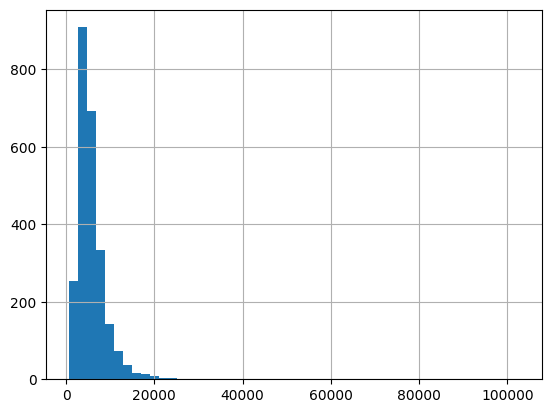

In [21]:
# step 3: 单变量分布
# numberical columns
loans_df["Monthly.Income"].hist(bins=50)
loans_df["Monthly.Income"].describe()

In [22]:
# categorical columns
loans_df["Loan.Purpose"].value_counts()

Loan.Purpose
debt_consolidation    1307
credit_card            444
other                  200
home_improvement       152
major_purchase         101
small_business          87
car                     50
wedding                 39
medical                 30
moving                  29
vacation                21
house                   20
educational             15
renewable_energy         4
Name: count, dtype: int64

In [ ]:
# step 4: 目标变量
# loans_df["Interest.Rate"] = loans_df["Interest.Rate"].str.rstrip("%").astype(float)
loans_df["Interest.Rate"].head(10)


0     8.90
1    12.12
2    21.98
3     9.99
4    11.71
5    15.31
6     7.90
7    17.14
8    14.33
9     6.91
Name: Interest.Rate, dtype: float64

<Axes: xlabel='FICO.Range', ylabel='Interest.Rate'>

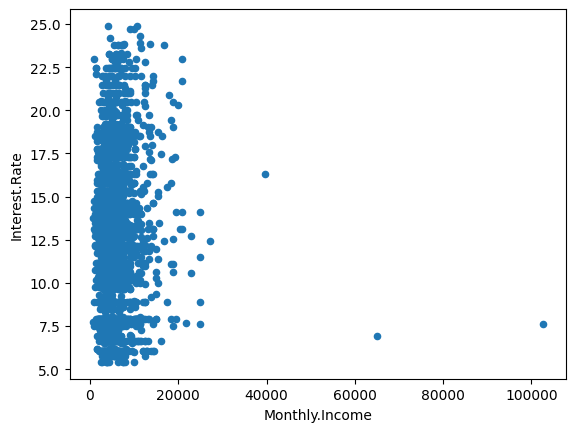

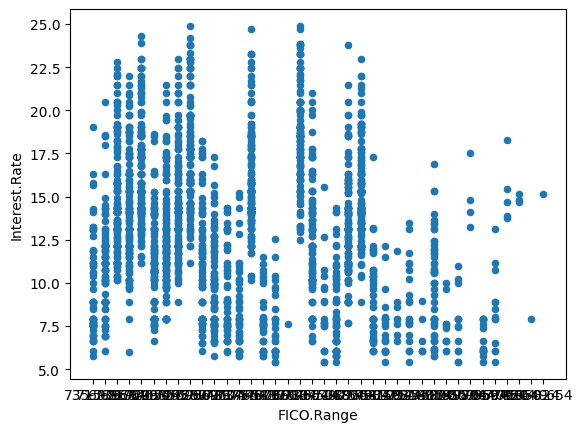

In [31]:
#step 5: 变量关系
loans_df.plot.scatter(x="Monthly.Income", y="Interest.Rate")
loans_df.plot.scatter(x="FICO.Range", y="Interest.Rate")

In [32]:
#step 6 : 相关性
import seaborn as sns
sns.heatmap(loans_df.corr(), annot=True, cmap="coolwarm")

ValueError: could not convert string to float: '.'

In [35]:
# step 7:异常性
loans_df["Monthly.Income"].sort_values(ascending=False).head(10)
#loans_df.boxplot(column="Monthly.Income", by="Loan.Purpose")

1851    102750.00
267      65000.00
1998     39583.33
1426     27083.33
213      25000.00
1228     25000.00
1658     25000.00
2477     25000.00
1318     22916.67
770      22916.67
Name: Monthly.Income, dtype: float64